<a href="https://colab.research.google.com/github/rachakondasaivarshini/GAN-PROGRAMS/blob/main/GAN_EXP6_prelab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
After reshaping: (60000, 784)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 559,632 (2.13 MB)

 Trainable params: 559,632 (2.13 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20 | Generator Loss: 6.4331 | Discriminator Loss: 0.1251
Epoch 2/20 | Generator Loss: 6.5402 | Discriminator Loss: 0.1354
Epoch 3/20 | Generator Loss: 4.1714 | Discriminator Loss: 0.1257
Epoch 4/20 | Generator Loss: 5.0002 | Discriminator Loss: 0.0622
Epoch 5/20 | Generator Loss: 5.6041 | Discriminator Loss: 0.0575
Epoch 6/20 | Generator Loss: 6.1494 | Discriminator Loss: 0.4494
Epoch 7/20 | Generator Loss: 4.9846 | Discriminator Loss: 0.5315
Epoch 8/20 | Generator Loss: 6.2135 | Discriminator Loss: 0.1386
Epoch 9/20 | Generator Loss: 5.2912 | Discriminator Loss: 0.1539
Epoch 10/20 | Generator Loss: 5.0064 | Discriminator Loss: 0.1682
Epoch 11/20 | Generator Loss: 5.3130 | Discriminator Loss: 0.1184
Epoch 12/20 | Generator Loss: 6.7498 | Discriminator Loss: 0.3610
Epoch 13/20 | Generator Loss: 4.8488 | Discriminator Loss: 0.2270
Epoch 14/20 | Generator Loss: 4.3341 | Discriminator Loss: 0.3989
Epoch 15/20 | Generator Loss: 4.6454 | Discriminator Loss: 0.4100
Epoch 16/20 | Gener

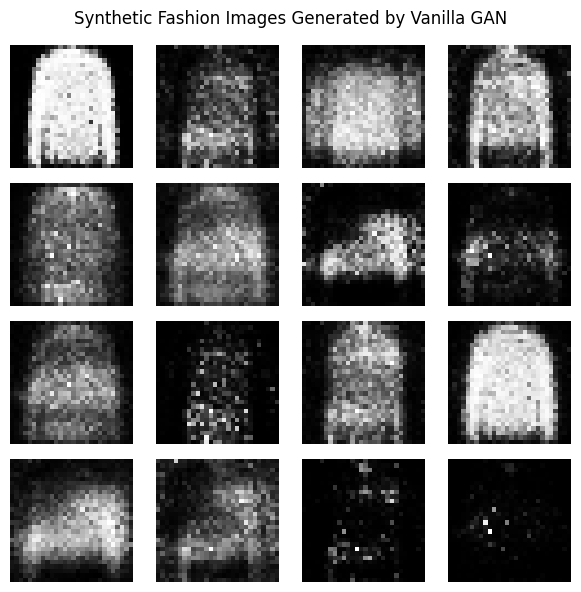

In [ ]:
# ============================================================
# VANILLA GAN USING FASHION-MNIST
# Aim: Generate synthetic clothing images using GAN
# ============================================================

# 1. Import required libraries
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 2. Load Fashion-MNIST Dataset
# ------------------------------------------------------------

# We only need training images; labels are not required for GAN
(x_train, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

print("Training images shape:", x_train.shape)

# Normalize images from [0, 255] to [-1, 1]
# This matches the tanh activation used in the Generator
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

# Flatten each 28x28 image into 784 values
x_train = x_train.reshape(-1, 784)

print("After reshaping:", x_train.shape)

# ------------------------------------------------------------
# 3. Create Dataset Batches
# ------------------------------------------------------------

BUFFER_SIZE = 60000
BATCH_SIZE = 256

dataset = (
    tf.data.Dataset
    .from_tensor_slices(x_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)

# ------------------------------------------------------------
# 4. Build the Generator
# ------------------------------------------------------------

# Generator takes random noise and creates a fake image

generator = tf.keras.Sequential([
    layers.Input(shape=(100,)),

    layers.Dense(256),
    layers.LeakyReLU(negative_slope=0.2),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.2),

    layers.Dense(784, activation="tanh")
])

generator.summary()

# ------------------------------------------------------------
# 5. Build the Discriminator
# ------------------------------------------------------------

# Discriminator checks whether an image is real or fake

discriminator = tf.keras.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.2),

    layers.Dense(256),
    layers.LeakyReLU(negative_slope=0.2),

    # Output:
    # Close to 1 = Real image
    # Close to 0 = Fake image
    layers.Dense(1, activation="sigmoid")
])

discriminator.summary()

# ------------------------------------------------------------
# 6. Define Optimizers and Loss Function
# ------------------------------------------------------------

loss_function = tf.keras.losses.BinaryCrossentropy()

generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002
)

# ------------------------------------------------------------
# 7. Training Function
# ------------------------------------------------------------

def train_step(real_images):

    # Get current batch size
    batch_size = tf.shape(real_images)[0]

    # Generate random noise
    noise = tf.random.normal([batch_size, 100])

    # --------------------------------------------------------
    # Train Discriminator
    # --------------------------------------------------------

    with tf.GradientTape() as disc_tape:

        # Generator creates fake images
        fake_images = generator(noise, training=True)

        # Discriminator predictions
        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)

        # Loss for real images
        real_loss = loss_function(
            tf.ones_like(real_output),
            real_output
        )

        # Loss for fake images
        fake_loss = loss_function(
            tf.zeros_like(fake_output),
            fake_output
        )

        # Total discriminator loss
        discriminator_loss = real_loss + fake_loss

    # Calculate discriminator gradients
    discriminator_gradients = disc_tape.gradient(
        discriminator_loss,
        discriminator.trainable_variables
    )

    # Apply discriminator gradients
    discriminator_optimizer.apply_gradients(
        zip(
            discriminator_gradients,
            discriminator.trainable_variables
        )
    )

    # --------------------------------------------------------
    # Train Generator
    # --------------------------------------------------------

    # Generate new random noise
    noise = tf.random.normal([batch_size, 100])

    with tf.GradientTape() as gen_tape:

        # Generate fake images
        fake_images = generator(noise, training=True)

        # Discriminator predicts fake images
        fake_output = discriminator(fake_images, training=True)

        # Generator wants discriminator to classify
        # fake images as REAL (1)
        generator_loss = loss_function(
            tf.ones_like(fake_output),
            fake_output
        )

    # Calculate generator gradients
    generator_gradients = gen_tape.gradient(
        generator_loss,
        generator.trainable_variables
    )

    # Apply generator gradients
    generator_optimizer.apply_gradients(
        zip(
            generator_gradients,
            generator.trainable_variables
        )
    )

    return generator_loss, discriminator_loss


# ------------------------------------------------------------
# 8. Train the GAN
# ------------------------------------------------------------

EPOCHS = 20

for epoch in range(EPOCHS):

    gen_loss = 0
    disc_loss = 0

    for batch in dataset:

        gen_loss, disc_loss = train_step(batch)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Generator Loss: {gen_loss.numpy():.4f} | "
        f"Discriminator Loss: {disc_loss.numpy():.4f}"
    )

print("\nGAN Training Completed!")

# ------------------------------------------------------------
# 9. Generate Synthetic Clothing Images
# ------------------------------------------------------------

# Generate 16 random noise vectors
noise = tf.random.normal([16, 100])

# Generator creates 16 synthetic images
generated_images = generator(noise, training=False)

# Convert values from [-1, 1] back to [0, 1]
generated_images = (generated_images + 1) / 2.0

# ------------------------------------------------------------
# 10. Display Generated Images
# ------------------------------------------------------------

plt.figure(figsize=(6, 6))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    # Convert 784 values back to 28x28 image
    image = generated_images[i].numpy().reshape(28, 28)

    plt.imshow(image, cmap="gray")
    plt.axis("off")

plt.suptitle("Synthetic Fashion Images Generated by Vanilla GAN")
plt.tight_layout()
plt.show()